In [ ]:


import torch
import math
import numpy as np
import pickle
import matplotlib.pyplot as plt
import os


In [2]:
#change work directory
path_project="/home/shij0d/Documents/Dis_Spatial"
os.chdir(path_project)


In [7]:
path_results='real_data/Second_scenario/RMSPE_varying_m/result_prediction_varying_m_grid_knots.pkl'
path_results_more='real_data/Second_scenario/RMSPE_varying_m/result_prediction_varying_m_grid_knots_more.pkl'
path_true='real_data/Second_scenario/RMSPE_varying_m/result_prediction_y_true.pkl'

with open(path_results, 'rb') as f:
    results=pickle.load(f)
with open(path_results_more, 'rb') as f:
    results_more=pickle.load(f)
with open(path_true, 'rb') as f:
    y_true=pickle.load(f)

M=len(results)
RMSPE=np.zeros((M,))
for m in range(M):
    if results[m][1]!=None:
        y_pre=results[m][1][0].reshape((-1,))
        RMSPE[m]=math.sqrt(torch.mean((y_pre-y_true)**2))
M=len(results_more)
RMSPE_more=np.zeros((M,))
for m in range(M):
    if results_more[m][1]!=None:
        y_pre=results_more[m][1][0].reshape((-1,))
        RMSPE_more[m]=math.sqrt(torch.mean((y_pre-y_true)**2))

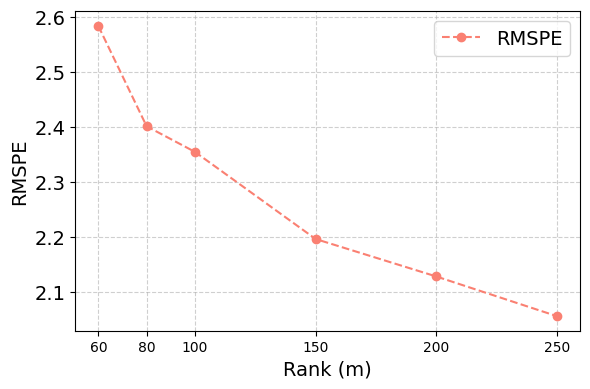

In [8]:
#ms=[60,70,80,90,100,150,200,250,300,400,500]
ms=[60,80,100,150,200,250]
RMSPE=RMSPE[[0,2,4,5,6,7]]
# Plot MLE and DE bars with colors and transparency
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ms, RMSPE, 'o--', label='RMSPE', color='salmon', markersize=6)
x_ticks=ms
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_ticks,fontsize=10)
ax.tick_params(axis='y', labelsize=14)

# Customize plot
ax.set_xlabel('Rank (m)',fontsize=14)
ax.set_ylabel('RMSPE',fontsize=14)
ax.legend(fontsize=14)
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()

plt.savefig("real_data/Second_scenario/RMSPE_varying_m/RMSPE_varying_m_sparser.pdf")
plt.show()